---
---


<div align=center>

# <span style="color:lightgreen">**Data Understanding, EDA and Data Quality**</span>

</div>

---
---

# <span style="color:lightgreen">**Part A**</span> - Dataset Understanding

In [113]:
import numpy as numpy
import pandas as pd
import matplotlib.pyplot as plt

In [80]:
# For train/test splitting:
from sklearn.model_selection import train_test_split

In [81]:
# Load the dataset
df = pd.read_csv("../Datasets/CaliforniaHousing.csv")

In [82]:
# Displaying it
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
0,5.3668,27.0,6.702899,1.028986,1793.0,3.248188,33.92,-117.98,2.198
1,3.4919,44.0,5.138418,1.031073,1137.0,3.211864,37.75,-122.50,2.718
2,1.6196,38.0,3.830116,1.077220,732.0,2.826255,37.75,-122.17,0.851
3,4.0926,42.0,4.525114,0.981735,717.0,3.273973,33.89,-118.09,1.644
4,3.9063,41.0,4.633540,0.900621,387.0,2.403727,37.69,-122.10,1.784
...,...,...,...,...,...,...,...,...,...
95,4.1050,16.0,6.035963,1.041763,2515.0,2.917633,32.83,-116.91,1.744
96,6.6073,17.0,6.771499,0.939803,2734.0,3.358722,34.29,-118.75,2.581
97,5.0758,35.0,6.378000,1.054000,1727.0,3.454000,34.05,-117.91,2.111
98,5.5061,17.0,6.923129,1.134862,4956.0,3.341875,34.46,-118.50,2.394


* *<span style="color:lightblue">**pd.read_csv():**</span> Reads a CSV file and converts it into a Pandas DataFrame.*

In [83]:
# Displaying the first five records
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
0,5.3668,27.0,6.702899,1.028986,1793.0,3.248188,33.92,-117.98,2.198
1,3.4919,44.0,5.138418,1.031073,1137.0,3.211864,37.75,-122.50,2.718
2,1.6196,38.0,3.830116,1.077220,732.0,2.826255,37.75,-122.17,0.851
3,4.0926,42.0,4.525114,0.981735,717.0,3.273973,33.89,-118.09,1.644
4,3.9063,41.0,4.633540,0.900621,387.0,2.403727,37.69,-122.10,1.784


In [84]:
# Displaying the last five records
df.tail()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
95,4.1050,16.0,6.035963,1.041763,2515.0,2.917633,32.83,-116.91,1.744
96,6.6073,17.0,6.771499,0.939803,2734.0,3.358722,34.29,-118.75,2.581
97,5.0758,35.0,6.378000,1.054000,1727.0,3.454000,34.05,-117.91,2.111
98,5.5061,17.0,6.923129,1.134862,4956.0,3.341875,34.46,-118.50,2.394
99,2.5313,30.0,5.039384,1.193493,NaN,2.679795,35.14,NaN,0.458


In [85]:
# Displaying the shape
df.shape

(100, 9)

In [86]:
# Displaying the columns
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseValue'],
      dtype='str')

In [87]:
# Number of samples
df.shape[0]

100

In [88]:
# Number of columns
df.shape[1] 

9


#### <span style="color:lightblue">**But be careful:**</span> Number of columns is not necessarily the same as number of features.

#### <span style="color:lightblue">**Why:**</span> Because one column may be the target variable.

> $Example: $ if there are 10 columns and one is the target:
>
> Samples  = 20,640
> 
> Features = 9
> 
> Target   = 1

You need to inspect the dataset before deciding.

In [89]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MedInc         100 non-null    float64
 1   HouseAge       100 non-null    float64
 2   AveRooms       99 non-null     float64
 3   AveBedrms      100 non-null    float64
 4   Population     97 non-null     float64
 5   AveOccup       99 non-null     float64
 6   Latitude       99 non-null     float64
 7   Longitude      96 non-null     float64
 8   MedHouseValue  100 non-null    float64
dtypes: float64(9)
memory usage: 7.2 KB


In [90]:
# Displaying the statistical summary
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
count,100.000000,100.000000,99.000000,100.000000,97.000000,99.000000,99.000000,96.000000,100.000000
mean,3.658175,28.860000,5.102687,1.048504,1526.123711,3.036994,35.560101,-119.535938,1.969290
std,1.441273,11.658456,1.155867,0.117671,1055.858865,0.648765,2.187016,2.030024,1.069005
min,1.225400,4.000000,2.096692,0.877301,240.000000,1.360332,32.710000,-124.130000,0.458000
25%,2.626625,18.000000,4.236945,1.006378,785.000000,2.633496,33.930000,-121.585000,1.327000
50%,3.491900,29.000000,5.152500,1.030534,1263.000000,2.935368,34.250000,-118.545000,1.659000
75%,4.406250,37.000000,5.912333,1.077766,1959.000000,3.350298,37.550000,-118.010000,2.541000
max,8.113200,52.000000,8.970968,1.990323,5587.000000,4.856655,40.920000,-116.910000,5.000010


| Statistic | Meaning                            |
| --------- | ---------------------------------- |
| `count`   | Number of non-missing observations |
| `mean`    | Average                            |
| `std`     | Standard deviation                 |
| `min`     | Minimum                            |
| `25%`     | First quartile                     |
| `50%`     | Median                             |
| `75%`     | Third quartile                     |
| `max`     | Maximum                            |

### **● Find the feature with the highest mean**

In [91]:
df.mean(numeric_only=True)

MedInc              3.658175
HouseAge           28.860000
AveRooms            5.102687
AveBedrms           1.048504
Population       1526.123711
AveOccup            3.036994
Latitude           35.560101
Longitude        -119.535938
MedHouseValue       1.969290
dtype: float64

In [92]:
df.mean(numeric_only=True).idxmax()

'Population'

In [93]:
df.mean(numeric_only=True).max()

np.float64(1526.1237113402062)

### **● Find the feature with the largest range**

*Remember →* `Range = Maximum - Minimum`

In [94]:
ranges = df.max(numeric_only=True) - df.min(numeric_only=True)

ranges

MedInc              6.887800
HouseAge           48.000000
AveRooms            6.874276
AveBedrms           1.113022
Population       5347.000000
AveOccup            3.496323
Latitude            8.210000
Longitude           7.220000
MedHouseValue       4.542010
dtype: float64

In [95]:
# Finding the largest
ranges.idxmax()

'Population'

In [96]:
# And its value
ranges.max

<bound method Series.max of MedInc              6.887800
HouseAge           48.000000
AveRooms            6.874276
AveBedrms           1.113022
Population       5347.000000
AveOccup            3.496323
Latitude            8.210000
Longitude           7.220000
MedHouseValue       4.542010
dtype: float64>

### **● Find the feature with the largest standard deviation**

In [97]:
df.std(numeric_only=True)

MedInc              1.441273
HouseAge           11.658456
AveRooms            1.155867
AveBedrms           0.117671
Population       1055.858865
AveOccup            0.648765
Latitude            2.187016
Longitude           2.030024
MedHouseValue       1.069005
dtype: float64

In [98]:
df.std(numeric_only=True).idxmax()

'Population'

### **● Minimum value of each feature**

In [99]:
df.min(numeric_only=True)

MedInc             1.225400
HouseAge           4.000000
AveRooms           2.096692
AveBedrms          0.877301
Population       240.000000
AveOccup           1.360332
Latitude          32.710000
Longitude       -124.130000
MedHouseValue      0.458000
dtype: float64

### **● Maximum value of each feature**

In [100]:
df.max(numeric_only=True)

MedInc              8.113200
HouseAge           52.000000
AveRooms            8.970968
AveBedrms           1.990323
Population       5587.000000
AveOccup            4.856655
Latitude           40.920000
Longitude        -116.910000
MedHouseValue       5.000010
dtype: float64

---
---

# <span style="color:lightgreen">**Part B**</span> - Exploratory Data Analysis

In [101]:
# This tells you how many missing values are there in each columns
df.isnull().sum()

MedInc           0
HouseAge         0
AveRooms         1
AveBedrms        0
Population       3
AveOccup         1
Latitude         1
Longitude        4
MedHouseValue    0
dtype: int64

In [102]:
# We can also check whether *any* missing value exists (this tells you --> Does at least one missing value exist?)
df.isnull().values.any()

np.True_

In [103]:
# This tells you how many duplicate rows exist.
df.duplicated().sum()

np.int64(4)

In [104]:
# Removing any duplicated values and updating the shape
df = df.drop_duplicates()

In [105]:
df.shape

(96, 9)

<div align="center">

# <span style="color:lightgreen">**Generating histograms**</span>

</div>

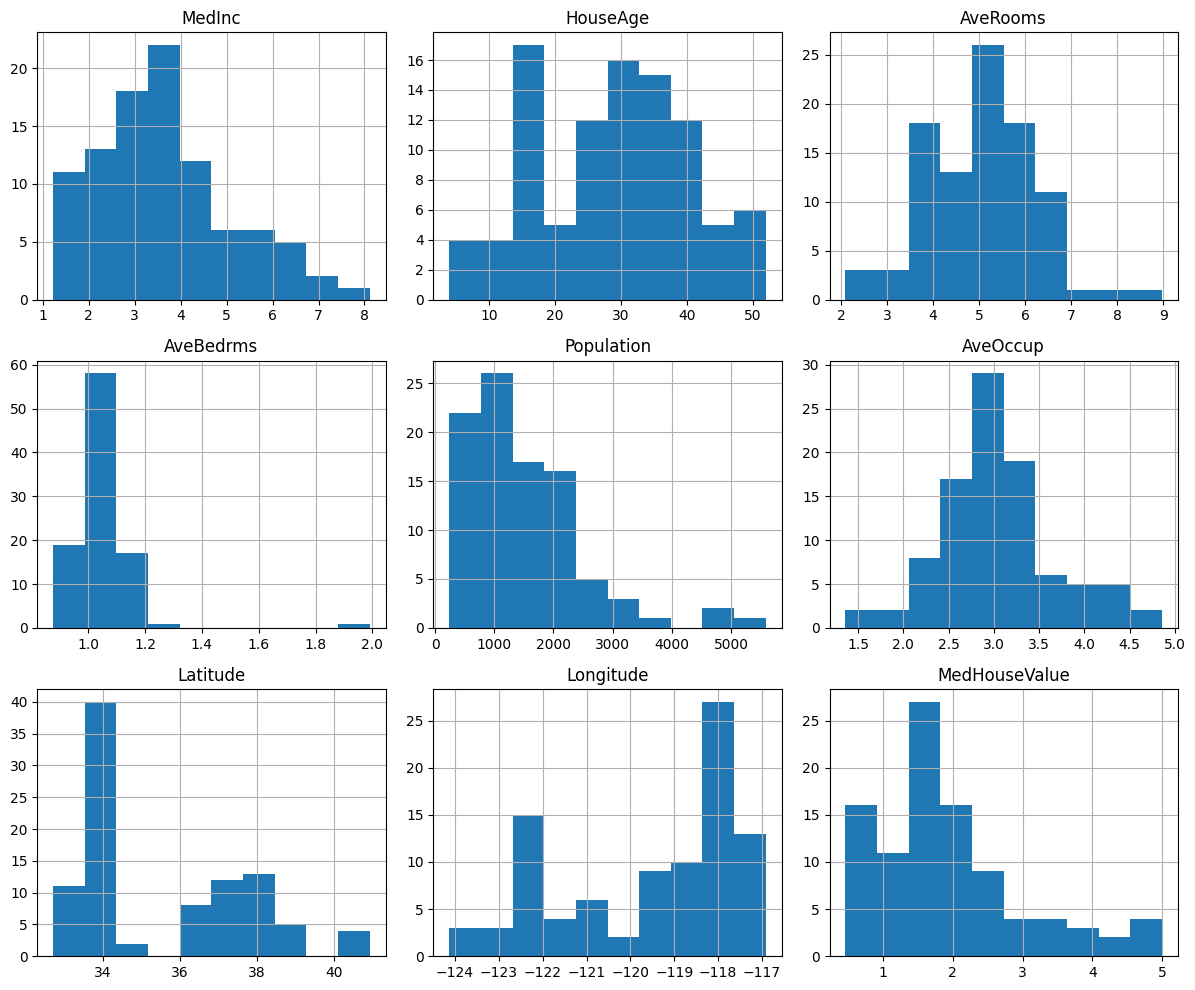

In [106]:
# Simple way
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

Now inspect the distributions.

You need to identify:

* Which feature looks normally distributed?

* Which feature appears skewed?

* Which feature contains the largest spread?

<center>

## **Important theory -** <span style="color:green"><u>**Histogram**</u></span>

</center>

A histogram shows the distribution of a variable.

It helps us understand:
* Center
* Spread
* Shape
* Skewness
* Possible unusual values

### **Normal distribution**

Roughly:

```python
        /\
       /  \
      /    \
_____/      \_____
```
*Symmetrical and bell-shaped.*


### **Right-skewed distribution**

```python
      /\
     /  \
____/    \____________
```

*Long tail toward the right.*

## **Choose an imputation method**

The lab asks you to choose an appropriate missing-value imputation method for each variable based on its distribution and justify your choice.

<div align=center>

### <span style="color:lightblue">**Mean imputation**</span>

</div>

In [107]:
# df["column"] = df["column"].fillna(df["column"].mean())

df["MedInc"] = df["MedInc"].fillna(df["MedInc"].mean())

**Good When:**

* Distribution is reasonably symmetric

* There aren't significant outliers

<div align=center>

### <span style="color:lightblue">**Median imputation**</span>

</div>

In [108]:
# df["column"] = df["column"].fillna(df["column"].median())

df["MedInc"] = df["MedInc"].fillna(df["MedInc"].median())

**Often preferable when:**

* Distribution is skewed

* Outliers exist

<div align=center>

### <span style="color:lightblue">**Mode imputation**</span>

</div>

In [109]:
# df["column"] = df["column"].fillna(df["column"].mode()[0])

**Usually used for:**

* Categorical variables

**Step 1 - Check whether MedInc actually has missing values**

In [110]:
df["MedInc"].isnull().sum()

np.int64(0)

There were no missing MedInc values to impute in the first place.

In [111]:
# To check which variables contain missing values.

df.isnull().sum()

MedInc           0
HouseAge         0
AveRooms         1
AveBedrms        0
Population       3
AveOccup         1
Latitude         1
Longitude        4
MedHouseValue    0
dtype: int64

<div align=center>

## <span style="color:green"><u>**Box Plots**</u></span>

</div>

### Generate separate boxplots for each numerical feature.

In [118]:
# To get numerical columns:

import numpy as np

numeric_columns = df.select_dtypes(include=np.number).columns

numeric_columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseValue'],
      dtype='str')

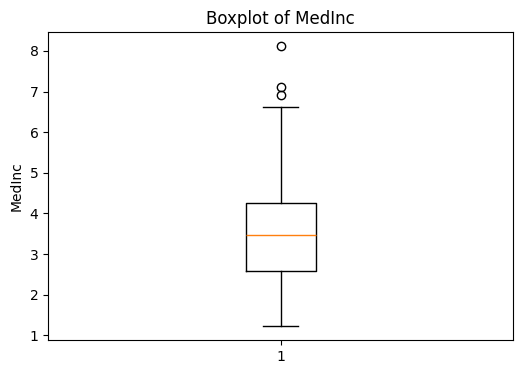

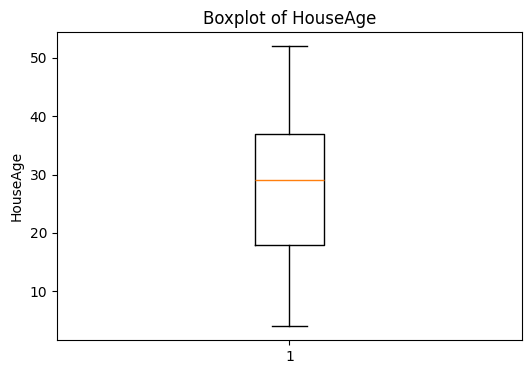

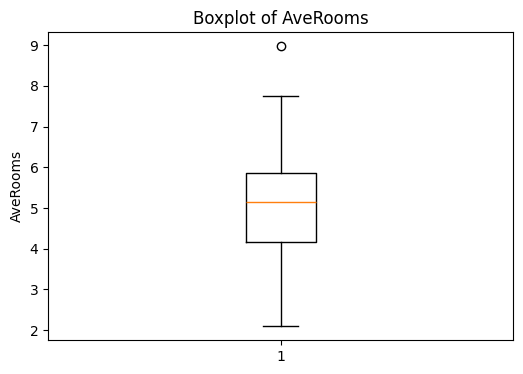

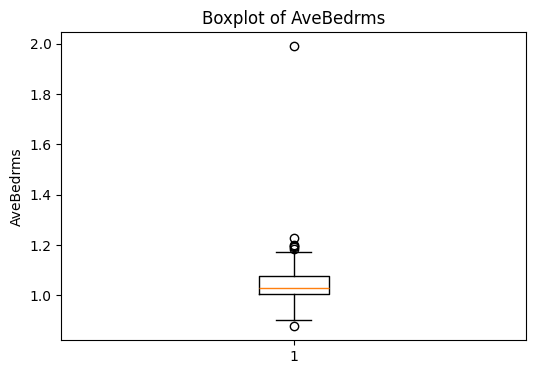

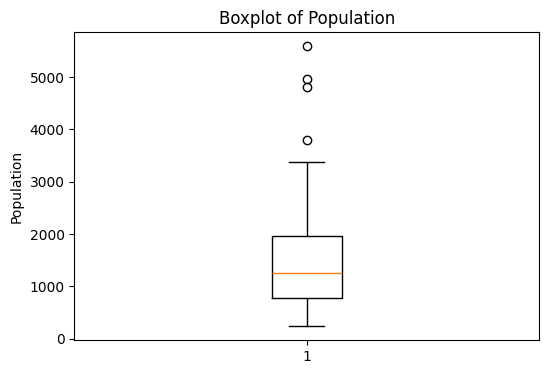

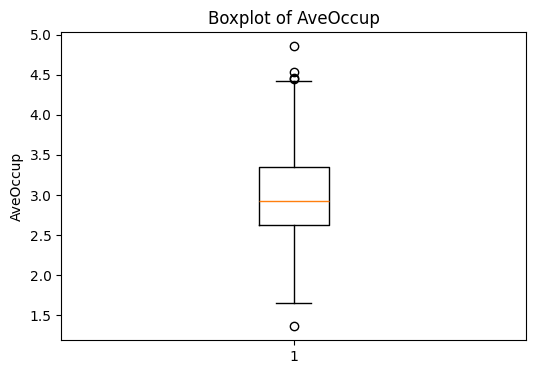

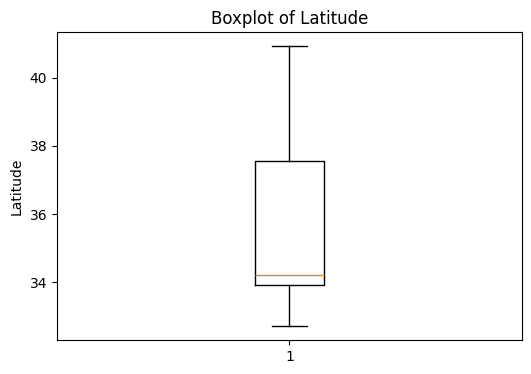

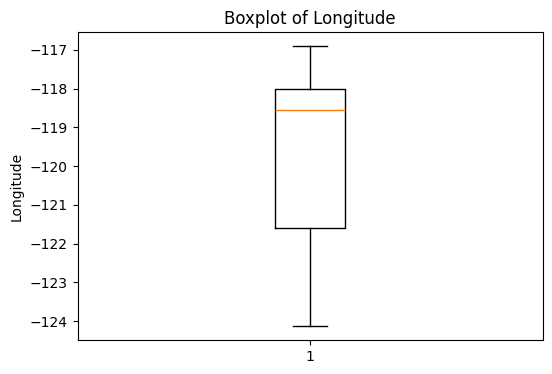

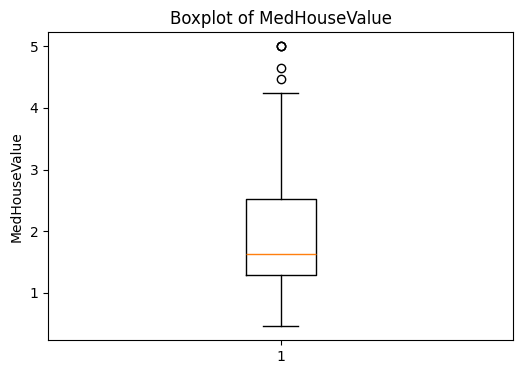

In [119]:
# looping through the numerical columns:

for column in numeric_columns:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[column].dropna())
    plt.title(f"Boxplot of {column}")
    plt.ylabel(column)
    plt.show()

<center>

### <span style="color:lightgreen">**Understand a Boxplot**</span>

</center>

A boxplot helps identify:

* Median

* Quartiles

* Spread

* Potential outliers

A simplified representation:

```python
       o        ← possible outlier
       |
   ┌───────┐
   │       │
───│───┼───│───
   │       │
   └───────┘
       |
```

***Outlier -** An observation that is unusually far from the majority of the data.*

### Why are outliers important in ML?

> Outliers can strongly affect statistical measures and some machine learning algorithms. They may distort relationships, affect model parameters and reduce predictive performance.

<div align=center>

## <span style="color:green"><u>**Scatter plot**</u></span>

</div>

The lab specifically asks for:

    Median Income vs Median House Value

In [120]:
# First identifying the exact column names in the DataFrame:

df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseValue'],
      dtype='str')

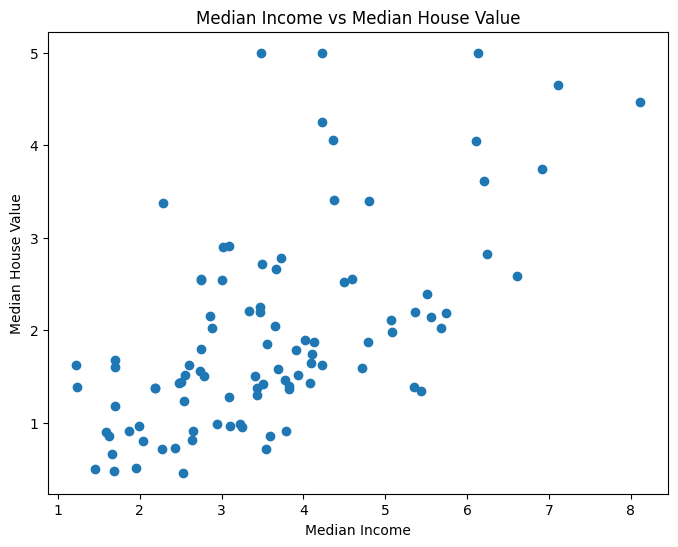

In [122]:
plt.figure(figsize=(8, 6))

plt.scatter(df["MedInc"], df["MedHouseValue"])

plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Median Income vs Median House Value")

plt.show()

**What should you interpret?**

Look for:

* Direction
* Strength
* Pattern
* Possible clusters
* Outliers

If higher income generally corresponds to higher house values, that suggests a positive relationship.

<div align=center>

## <span style="color:green"><u>**Correlation matrix**</u></span>

</div>

The lab asks you to generate a correlation matrix using a heatmap.

In [123]:
# Calculate correlation:
correlation_matrix = df.corr(numeric_only=True)

In [124]:
# Display it:
correlation_matrix

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
MedInc,1.000000,-0.140667,0.592696,-0.215994,0.101677,-0.184385,-0.121086,0.039368,0.608641
HouseAge,-0.140667,1.000000,-0.126994,-0.079394,-0.384556,-0.041282,-0.015700,-0.068222,0.268372
AveRooms,0.592696,-0.126994,1.000000,0.255618,-0.068368,-0.008720,0.152678,-0.117551,0.090766
AveBedrms,-0.215994,-0.079394,0.255618,1.000000,0.076984,-0.037270,0.098596,-0.112025,-0.084404
Population,0.101677,-0.384556,-0.068368,0.076984,1.000000,0.319410,-0.229130,0.237433,0.021631
AveOccup,-0.184385,-0.041282,-0.008720,-0.037270,0.319410,1.000000,-0.188026,0.292836,-0.436970
Latitude,-0.121086,-0.015700,0.152678,0.098596,-0.229130,-0.188026,1.000000,-0.940713,-0.137020
Longitude,0.039368,-0.068222,-0.117551,-0.112025,0.237433,0.292836,-0.940713,1.000000,-0.063292
MedHouseValue,0.608641,0.268372,0.090766,-0.084404,0.021631,-0.436970,-0.137020,-0.063292,1.000000


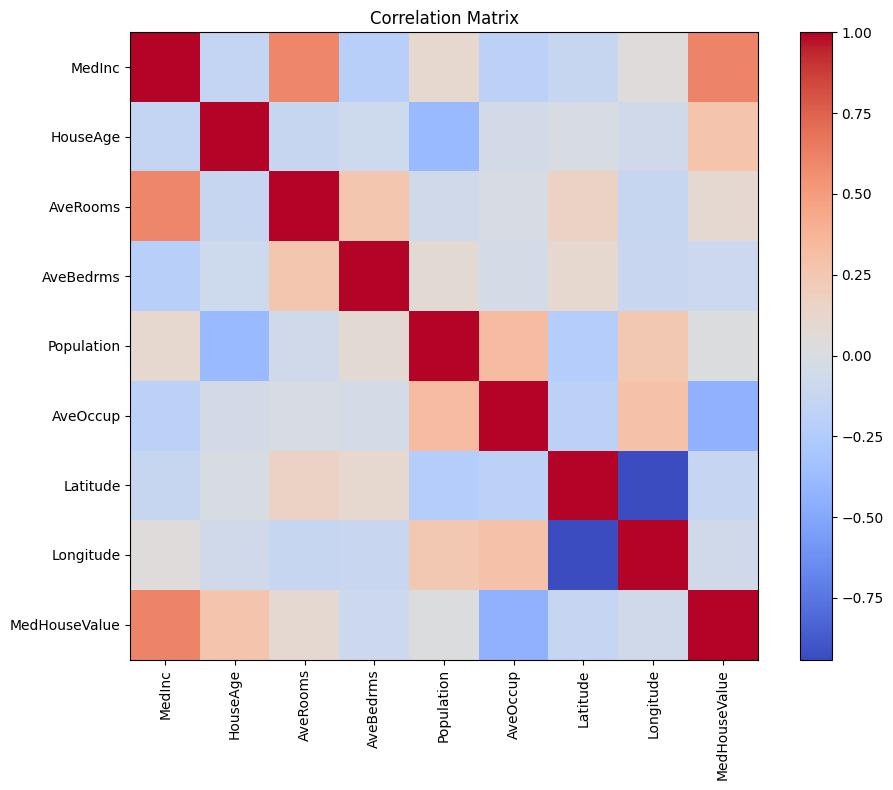

In [125]:
# Then visualize it:

plt.figure(figsize=(10, 8))

plt.imshow(correlation_matrix, cmap="coolwarm", interpolation="none")
plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

Correlation values range from: `-1 to +1`


**+1** » Perfect positive relationship. **X ↑ → Y ↑**

**-1** » Perfect negative relationship. **X ↑ → Y ↓**

**0** » Little or no linear relationship.

## **Most positively correlated feature with target**

First determine your target column.

Then you can inspect:

In [126]:
# correlation_matrix[target_column].sort_values(ascending=False)

For example, if the target is: `target_column = "MedHouseVal"`

then: 
```python
correlation_matrix["MedHouseVal"].sort_values(ascending=False)
```

---

<span style="color:red">**Important:**</span> The target itself will have correlation 1.0 with itself, so when answering:

> "Which feature is most positively correlated with the target?"

you should exclude the target itself.

---

## **Least correlated feature**

Again: 
```python
correlation_matrix["MedHouseVal"].sort_values()
```

Look at the feature with the correlation closest to zero.

---

<span style="color:red">**Remember:**</span> **"Least correlated"** means closest to zero, not necessarily the most negative.

---

## **Strongest correlation between two input variables**

You need to exclude the target and avoid counting a variable's correlation with itself.

This is a little more advanced.

In [127]:
# This removes the target variable from the DataFrame.
features = df.drop(columns=["MedHouseValue"])
# calculates the correlation between the input features.
feature_corr = features.corr()
# displays the correlation matrix.
feature_corr

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
MedInc,1.000000,-0.140667,0.592696,-0.215994,0.101677,-0.184385,-0.121086,0.039368
HouseAge,-0.140667,1.000000,-0.126994,-0.079394,-0.384556,-0.041282,-0.015700,-0.068222
AveRooms,0.592696,-0.126994,1.000000,0.255618,-0.068368,-0.008720,0.152678,-0.117551
AveBedrms,-0.215994,-0.079394,0.255618,1.000000,0.076984,-0.037270,0.098596,-0.112025
Population,0.101677,-0.384556,-0.068368,0.076984,1.000000,0.319410,-0.229130,0.237433
AveOccup,-0.184385,-0.041282,-0.008720,-0.037270,0.319410,1.000000,-0.188026,0.292836
Latitude,-0.121086,-0.015700,0.152678,0.098596,-0.229130,-0.188026,1.000000,-0.940713
Longitude,0.039368,-0.068222,-0.117551,-0.112025,0.237433,0.292836,-0.940713,1.000000


Then inspect the matrix to find the strongest relationship between two different input features.

---
---

# <span style="color:lightgreen">**Part C**</span> - Train/Test Separation

In [130]:
# Separate Features and Target

X = df.drop(columns=["MedHouseValue"])
y = df["MedHouseValue"]

# X = input features
# y = target

In [ ]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**What does test_size=0.2 mean?** 20% goes to testing.

Therefore:
* 80% → training
* 20% → testing

**What does random_state=42 do?** It makes the split reproducible.

If you run the code again, you get the same split.

In [134]:
# Display training samples
print("Training samples:", X_train.shape[0])

Training samples: 76


In [135]:
# Display testing samples
print("Testing samples:", X_test.shape[0])

Testing samples: 20


In [136]:
# Check the distributions

# Start with: 
X_train.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,76.000000,76.000000,75.000000,76.000000,73.000000,75.000000,75.000000,72.000000
mean,3.552303,29.184211,5.078142,1.049236,1496.356164,3.097432,35.794933,-119.710972
std,1.502549,11.536274,1.166594,0.127990,1010.668183,0.681084,2.202415,2.039486
min,1.225400,4.000000,2.096692,0.877301,240.000000,1.654163,32.710000,-124.130000
25%,2.523475,18.750000,4.171829,1.006378,781.000000,2.647950,34.025000,-121.935000
50%,3.420050,29.000000,5.193548,1.025722,1167.000000,2.935368,34.290000,-119.080000
75%,4.228950,38.000000,5.863680,1.069792,1959.000000,3.411287,37.550000,-118.115000
max,8.113200,52.000000,8.970968,1.990323,5587.000000,4.856655,40.920000,-116.910000


In [137]:
# and: 
X_test.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,3.825410,28.050000,5.057465,1.049776,1517.400000,2.784915,34.827500,-118.967000
std,1.175705,12.445566,1.162226,0.079058,1043.923692,0.510077,2.046859,1.940008
min,1.703800,5.000000,2.615836,0.900621,317.000000,1.360332,32.730000,-122.440000
25%,3.071150,16.750000,4.235934,1.008798,980.500000,2.441346,33.485000,-120.085000
50%,3.595850,27.500000,4.917589,1.044373,1286.500000,2.902890,34.035000,-118.315000
75%,4.550200,35.250000,5.816098,1.105772,1858.250000,3.070567,36.992500,-117.740000
max,6.247300,52.000000,6.923129,1.194836,4956.000000,3.458904,38.580000,-117.030000


Compare:

* Mean

* Standard deviation

* Minimum

* Maximum

* Quartiles

### **Visualization**

For example, compare the distribution of one feature:

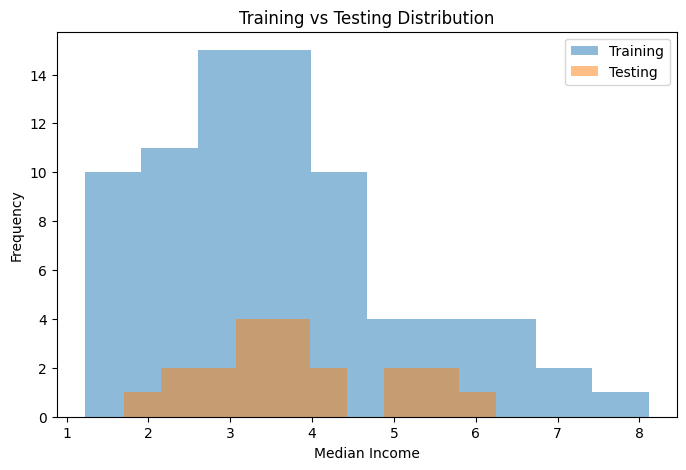

In [138]:
plt.figure(figsize=(8, 5))

plt.hist(X_train["MedInc"], alpha=0.5, label="Training")
plt.hist(X_test["MedInc"], alpha=0.5, label="Testing")

plt.xlabel("Median Income")
plt.ylabel("Frequency")
plt.title("Training vs Testing Distribution")
plt.legend()

plt.show()